In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

In [2]:
from y_n import y_n
from upsilon_n import upsilon_n

In [3]:
def rates(params):
    P_H2 = params['P_H2']
    P_CO = params['P_CO']
    T = params['T_K']
    n = params['n']
    E = ( params['E_HCs'] * ( ~n.isin( [1,2] ) ) + params['E_C1'] * ( n == 1 ) + params['E_C2'] * ( n == 2 ) )
    k_HCs = params['A_HCs'] * np.exp ( - E / ( 8.314 * T ) )
    K_CO =  params['k_ads'] * np.exp ( - params['H_ads'] / ( 8.314 * T ) )
    params['rate'] = (
        (params['para']) * y_n(n, T) * upsilon_n(n, T) * k_HCs * P_H2 ** 0.75 * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 ) + 
        (1 - params['para']) * y_n(n, T) * ( 1 - upsilon_n(n, T) ) * k_HCs * P_H2 ** 0.75 * P_CO / ( ( 1 + K_CO * P_CO ) ** 2 )
    )
    return params

In [4]:
param_grid = {'T_K'        : np.arange(210 + 273.15, 300 + 273.15, 20), 
              'P_H2'       : [20e5*0.667],
              'P_CO'       : [20e5*0.333],
              'A_HCs'      : [0.955061],
              'E_HCs'      : [147203.9259840268],
              'E_C1'       : [142601.814307],
              'E_C2'       : [153272.908181],
              'k_ads'      : [1.397972209918762e-05],
              'H_ads'      : [932.9790718460237],
              'n'          : np.arange(1, 36, 1),
              'para'       : [True, False],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))

In [5]:
parametric_data = rates(parametric_data)
# to remove rate = 0 for n = 1 and para = False
parametric_data = parametric_data.loc[parametric_data.rate != 0]

In [6]:
parametric_data['log rate'] = np.log(parametric_data.rate)
parametric_data['-1/RT'] = - 1 / ( 8.314 * parametric_data.T_K )

In [7]:
parametric_data

,A_HCs,E_C1,E_C2,E_HCs,H_ads,P_CO,P_H2,T_K,k_ads,n,para,rate,log rate,-1/RT
0,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,483.15,0.000014,1,True,1.304622e-08,-18.154767,-0.000249
2,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,483.15,0.000014,2,True,3.973216e-10,-21.646275,-0.000249
3,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,483.15,0.000014,2,False,4.304829e-10,-21.566114,-0.000249
4,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,483.15,0.000014,3,True,3.390397e-09,-19.502319,-0.000249
6,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,483.15,0.000014,4,True,4.693666e-10,-21.479637,-0.000249
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,563.15,0.000014,33,False,4.499004e-14,-30.732335,-0.000214
346,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,563.15,0.000014,34,True,5.302778e-10,-21.357620,-0.000214
347,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,563.15,0.000014,34,False,2.535860e-14,-31.305659,-0.000214
348,0.955061,142601.814307,153272.908181,147203.925984,932.979072,666000.0,1334000.0,563.15,0.000014,35,True,4.159530e-10,-21.600449,-0.000214


In [8]:
from scipy.optimize import curve_fit

# 1. Define the model function
def linear_model(x, m, c):
    return m * x + c

# 2. Define the fitting wrapper for pandas .apply()
def fit_group(group):
    # Perform the curve fit
    popt, _ = curve_fit(linear_model, group['-1/RT'], group['log rate'])
    # Return coefficients as a Series for easy combining
    return pd.Series({'slope': popt[0], 'intercept': popt[1]})

# 3. Apply to grouped data
results = parametric_data.groupby(['n', 'para']).apply(fit_group, include_groups=False)

In [9]:
results.loc[(1, slice(None)), :] = 142601.814307

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

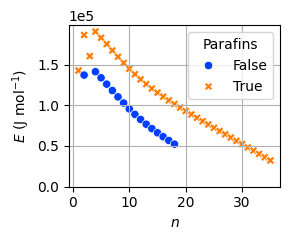

In [23]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.scatterplot(data = results.drop(results.loc[(range(19,36), False),:].index),
            x = 'n', y = 'slope', 
             hue = 'para', style = 'para', palette = 'bright', ax = ax
            )
plt.grid('both')
plt.ylabel(r'$E~\mathrm{(J~mol^{-1})}$')
plt.xlabel(r'$n$')
plt.legend(title = 'Parafins')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.ylim(0, None)

plt.tight_layout()
fig_name = 'activation_energies.pdf'
plt.savefig('/home/rafael/GoogleDrive/uem/Doutorado/Papers/SAF_kinetics/figures/'+fig_name, 
            bbox_inches = 'tight')

plt.show()